In [ ]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import umap
from karateclub import Graph2Vec
import pickle
import random
import seaborn as sns
from karateclub import FeatherGraph

In [2]:
# Open data
with open("../GT_Tools_producing_data/Intermediate_outputs_1/data_1.pkl", "rb") as f:
    data_1 = pickle.load(f)

with open("../GT_Tools_producing_data/Intermediate_outputs_2/data_2.pkl", "rb") as f:
   data_2 = pickle.load(f)

with open("../GT_Tools_producing_data/Intermediate_outputs_3/data_3.pkl", "rb") as f:
    data_3 = pickle.load(f)

with open("../GT_Tools_producing_data/Intermediate_outputs_4/data_4.pkl", "rb") as f:
    data_4 = pickle.load(f)

with open("../GT_Tools_producing_data/Intermediate_outputs_5/data_5.pkl", "rb") as f:
    data_5 = pickle.load(f)

with open("../GT_Tools_producing_data/Intermediate_outputs_6/data_6.pkl", "rb") as f:
    data_6 = pickle.load(f)

with open("../GT_Tools_producing_data/Intermediate_outputs_7/data_7.pkl", "rb") as f:
    data_7 = pickle.load(f)

print( len(data_1) +len(data_2) + len(data_3) + len(data_4)+ len(data_5) + len(data_6) + len(data_7))  

data ={}
for name, g in data_1.items():
    data[name] = g

for name, g in data_2.items():
    data[name] = g

for name, g in data_3.items():
    data[name] = g
    
for name, g in data_4.items():
    data[name] = g
    
for name, g in data_5.items():
    data[name] = g

for name, g in data_6.items():
    data[name] = g

for name, g in data_7.items():
    data[name] = g
print(len(data))

50
50


In [ ]:
# Store DataFrames in Categories
bio = []
infrastructure = []
social = []
tech = []
animal = []
collab =[]

g_bio = {}
g_infrastructure = {}
g_social = {}
g_tech = {}
g_animal = {}
g_collab = {}

for name, g in data_1.items():
    if name == "E-road":
        infrastructure.append(name)
        g_infrastructure[name] = g
    elif name =="C. Elegans":
        bio.append(name)
        g_bio[name] = g
    elif ("ollab" in name) :
        collab.append(name)
        g_collab[name] = g
    else: 
        social.append(name)
        g_social[name] = g

for name, g in data_2.items():
    bio.append(name)
    g_bio[name] = g


for name, g in data_3.items():
    if "Oregon" in name:
        tech.append(name)
        g_tech[name] = g
    elif "ollab" in name:
        collab.append(name)
        g_collab[name] = g
    else:
        social.append(name)
        g_social[name] = g


for name, g in data_4.items():
    if "Bio" in name:
        bio.append(name)
        g_bio[name] = g
    elif ("Power" in name) :
        infrastructure.append(name)
        g_infrastructure[name] = g
    elif ("Tech" in name):
        tech.append(name)
        g_tech[name] = g
    else:
        animal.append(name)
        g_animal[name] = g

for name, g in data_5.items():
    if ("Tech" in name) or ("Web" in name):
        tech.append(name)
        g_tech[name] = g
    else: 
        infrastructure.append(name)
        g_infrastructure[name] = g

for name, g in data_6.items():
    if "ollab" in name:
        collab.append(name)
        g_collab[name] = g
    else:
        social.append(name)
        g_social[name] = g

for name, g in data_7.items():
    tech.append(name)
    g_tech[name] = g

# verify lengths are ok 
print( len(g_bio) + len(g_infrastructure)  +len(g_social) + len(g_tech)+ len(g_animal) + len(g_collab) ) 
print( len(bio) + len(social) + len(infrastructure) + len(tech) + len(animal) + len(collab) ) 

50
50


In [5]:
graphs = list(g_bio.values()) + list(g_infrastructure.values()) + list(g_tech.values())+ list(g_social.values()) + list(g_animal.values()) + list(g_collab.values())
names = bio + infrastructure + tech + social  + animal + collab 
labels = (["Bio"] * len(bio) + ["Infrastructure"] * len(infrastructure) + ["Tech\Web"]*len(tech) +  ["Social"] * len(social)+ ["Animal"] * len(animal) +["Collab"] * len(collab))

labels = np.array(labels)  # Convert to NumPy array

In [6]:
random.seed(42)
np.random.seed(42)

# Graph2Vec

C:\Users\Utente\anaconda3\envs\New_base\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


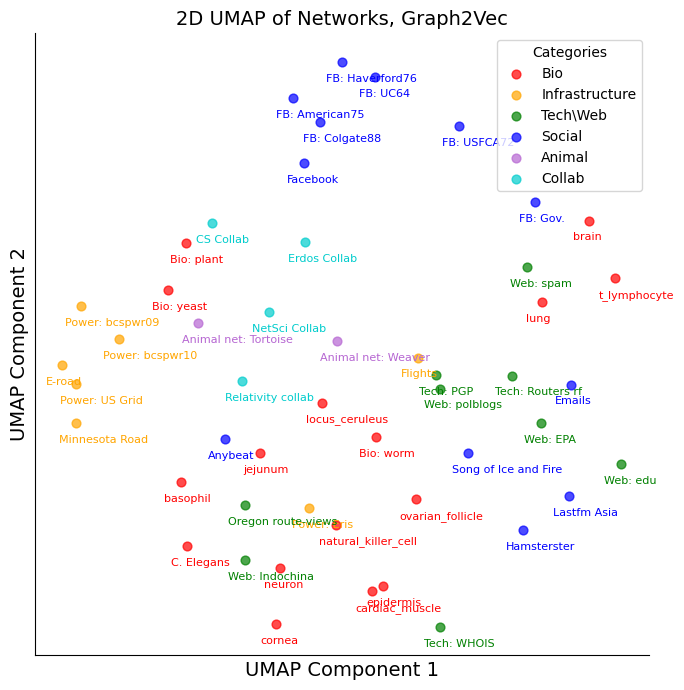

In [10]:
# Graph2Vec Embeddings
model = Graph2Vec(dimensions=128, wl_iterations=5, min_count=1, learning_rate=0.025)
model.fit(graphs)
graph_embeddings = np.array(model.get_embedding())

# UMAP
umap_model = umap.UMAP(n_components=2, random_state=42)
X_umap = umap_model.fit_transform(graph_embeddings)

# Names and labels must be predefined like before
# names = bio + infrastructure + tech + social + animal + collab
# labels = (["Bio"] * len(bio) + ["Infrastructure"] * len(infrastructure) + 
#           ["Tech\Web"] * len(tech) + ["Social"] * len(social) + 
#           ["Animal"] * len(animal) + ["Collab"] * len(collab)

# Define colors
group_colors = {
    "Bio": "red",
    "Infrastructure": "orange",
    "Tech\Web": "green",
    "Social": "blue",
    "Animal": "#B666D2",
    "Collab": "#00CCCC"
}

# Dummy measure for scaling (replace with real metric if available)
measure = np.ones((X_umap.shape[0], 1))

# Plot
plt.figure(figsize=(7, 7))
typecheck = {label: 0 for label in group_colors}

for i, name in enumerate(names):
    x, y = X_umap[i, 0], X_umap[i, 1]
    label = labels[i]
    color = group_colors[label]
    size = 40 * np.max(measure[i, :])  # Adjust this if using real measure

    if typecheck[label] == 0:
        plt.scatter(x, y, color=color, s=size, label=label, alpha=0.7, linewidths=1)
        typecheck[label] = 1
    else:
        plt.scatter(x, y, color=color, s=size, alpha=0.7, linewidths=1)

    # Annotate point
    plt.annotate(name, (x - 0.1, y - 0.15), fontsize=8, color=color)

# Final touches
plt.legend(loc="best", frameon=True, title="Categories")
plt.xlabel("UMAP Component 1", fontsize=14)
plt.ylabel("UMAP Component 2", fontsize=14)
plt.title("2D UMAP of Networks, Graph2Vec", fontsize=14)

# Remove axis ticks
plt.xticks([])
plt.yticks([])

sns.despine()
plt.tight_layout()
plt.savefig("UMAP_Graph2Vec_styled.pdf")

# FEATHER-G

C:\Users\Utente\anaconda3\envs\New_base\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


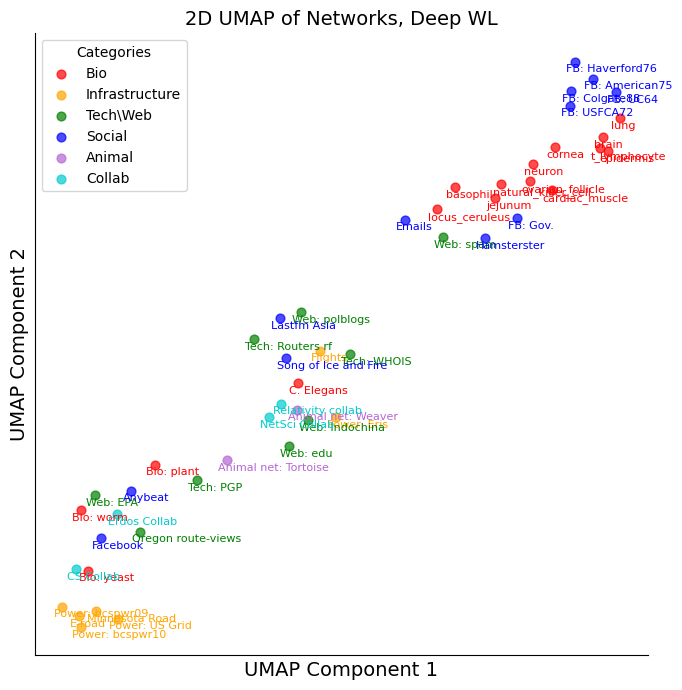

In [ ]:
# Feather-G embeddings
model = FeatherGraph()
model.fit(graphs)
graph_embeddings = model.get_embedding()

# UMAP to 2D
umap_model = umap.UMAP(n_components=2, random_state=42)
X_umap = umap_model.fit_transform(graph_embeddings)

# Define names and labels beforehand
# names = bio + infrastructure + tech + social + animal + collab
# labels = (["Bio"] * len(bio) + ["Infrastructure"] * len(infrastructure) + 
#           ["Tech\Web"] * len(tech) + ["Social"] * len(social) + 
#           ["Animal"] * len(animal) + ["Collab"] * len(collab)

# Define colors
group_colors = {
    "Bio": "red",
    "Infrastructure": "orange",
    "Tech\Web": "green",
    "Social": "blue",
    "Animal": "#B666D2",
    "Collab": "#00CCCC"
}

# Dummy size scaling
measure = np.ones((X_umap.shape[0], 1))

# Plot
plt.figure(figsize=(7, 7))
typecheck = {label: 0 for label in group_colors}

for i, name in enumerate(names):
    x, y = X_umap[i, 0], X_umap[i, 1]
    label = labels[i]
    color = group_colors[label]
    size = 40 * np.max(measure[i, :])

    if typecheck[label] == 0:
        plt.scatter(x, y, color=color, s=size, label=label, alpha=0.7, linewidths=1)
        typecheck[label] = 1
    else:
        plt.scatter(x, y, color=color, s=size, alpha=0.7, linewidths=1)

    # Annotate point
    plt.annotate(name, (x - 0.1, y - 0.15), fontsize=8, color=color)

# Styling
plt.legend(loc="best", frameon=True, title="Categories")
plt.xlabel("UMAP Component 1", fontsize=14)
plt.ylabel("UMAP Component 2", fontsize=14)
plt.title("2D UMAP of Networks, Feather-G", fontsize=14)

# No ticks
plt.xticks([])
plt.yticks([])

sns.despine()
plt.tight_layout()
plt.savefig("UMAP_FeatherG.pdf")